# # TASK 3: Visualisations



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv(r"C:\Users\Rohit\Downloads\shopease_orders_2023_2024.csv")
df

,order_id,order_date,year,month,customer_id,customer_age,customer_city,region,category,product_name,quantity,unit_price_inr,discount_pct,net_revenue_inr,payment_method,order_status,delivery_days,return_reason
0,ORD-2081,2023-01-03,2023,January,CUST-701,37,Nagpur,West,Toys & Games,Lego Set (200 pcs),3,7479.56,10,20194.81,COD,Delivered,12.0,NaN
1,ORD-2012,2023-01-04,2023,January,CUST-612,34,Pune,West,Toys & Games,Remote Control Car,3,3533.65,25,7950.71,UPI,Cancelled,NaN,NaN
2,ORD-2650,2023-01-04,2023,January,CUST-412,58,Lucknow,North,Home & Kitchen,Coffee Maker,6,3601.90,0,21611.40,Debit Card,Delivered,4.0,NaN
3,ORD-2188,2023-01-07,2023,January,CUST-557,33,Lucknow,North,Electronics,Power Bank,2,3870.89,5,7354.69,Debit Card,Delivered,7.0,NaN
4,ORD-2228,2023-01-07,2023,January,CUST-489,57,Guwahati,East,Clothing,Winter Jacket,4,944.08,10,3398.69,Debit Card,Delivered,6.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,ORD-2752,2024-12-29,2024,December,CUST-233,27,Ahmedabad,West,Books,Atomic Habits,5,7818.10,20,31272.40,UPI,Delivered,2.0,NaN
996,ORD-2868,2024-12-29,2024,December,CUST-148,38,Pune,West,Home & Kitchen,Coffee Maker,3,2971.25,15,7576.69,UPI,Delivered,4.0,NaN
997,ORD-2961,2024-12-29,2024,December,CUST-348,53,Guwahati,East,Toys & Games,Soft Plush Toy,1,2183.12,10,1964.81,Wallet,Delivered,6.0,NaN
998,ORD-2323,2024-12-30,2024,December,CUST-381,59,Bhopal,Central,Beauty,Face Wash,2,2092.88,10,3767.18,Net Banking,Cancelled,NaN,NaN


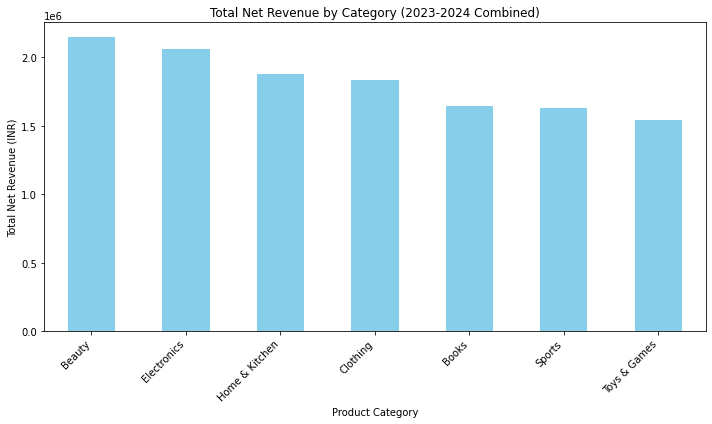

In [6]:
# Chart 1: Bar chart - Total net revenue by category (both years combined)
category_revenue = df.groupby('category')['net_revenue_inr'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
category_revenue.plot(kind='bar', color='skyblue')
plt.xlabel('Product Category')
plt.ylabel('Total Net Revenue (INR)')
plt.title('Total Net Revenue by Category (2023-2024 Combined)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

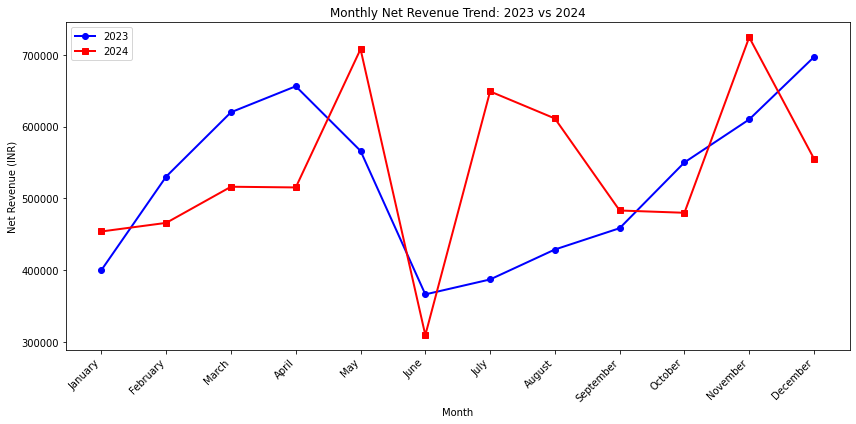

In [3]:
# Chart 2: Line chart - Monthly net revenue trend (show 2023 and 2024 as two separate lines)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_revenue = df.groupby(['year', 'month'])['net_revenue_inr'].sum().reset_index()
monthly_revenue['month'] = pd.Categorical(monthly_revenue['month'], categories=month_order, ordered=True)
monthly_revenue = monthly_revenue.sort_values(['year', 'month'])

revenue_2023 = monthly_revenue[monthly_revenue['year'] == 2023]
revenue_2024 = monthly_revenue[monthly_revenue['year'] == 2024]

plt.figure(figsize=(12, 6))
plt.plot(revenue_2023['month'], revenue_2023['net_revenue_inr'], marker='o', color='blue', label='2023', linewidth=2)
plt.plot(revenue_2024['month'], revenue_2024['net_revenue_inr'], marker='s', color='red', label='2024', linewidth=2)
plt.xlabel('Month')
plt.ylabel('Net Revenue (INR)')
plt.title('Monthly Net Revenue Trend: 2023 vs 2024')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

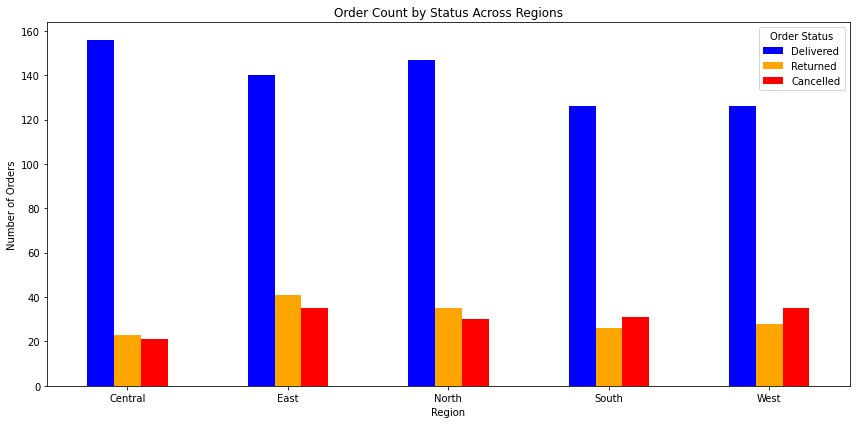

In [5]:
# Chart 3: Grouped bar - Order count by status (Delivered / Returned / Cancelled) per region
region_status = df.groupby(['region', 'order_status']).size().unstack(fill_value=0)

region_status[['Delivered', 'Returned', 'Cancelled']].plot(kind='bar', figsize=(12, 6), color=['Blue', 'orange', 'red'])
plt.xlabel('Region')
plt.ylabel('Number of Orders')
plt.title('Order Count by Status Across Regions')
plt.xticks(rotation=0)
plt.legend(title='Order Status')
plt.tight_layout()
plt.show()

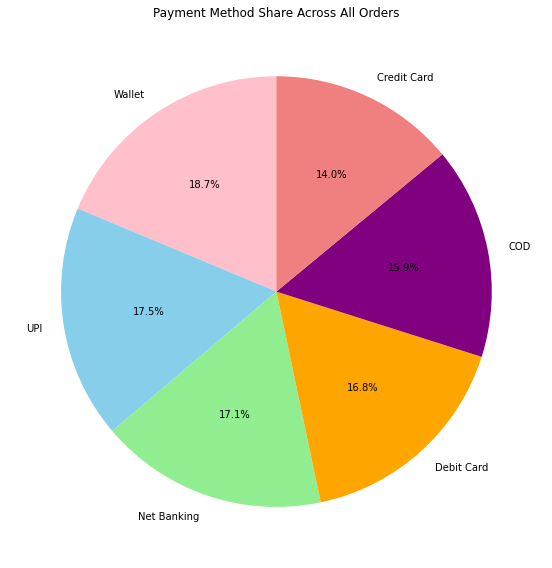

In [7]:
# Chart 4: Pie / Donut - Payment method share across all orders
payment_counts = df['payment_method'].value_counts()

plt.figure(figsize=(10, 8))
colors = ['pink', 'skyblue', 'lightgreen', 'orange', 'purple', 'lightcoral']
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Payment Method Share Across All Orders')
plt.tight_layout()
plt.show()

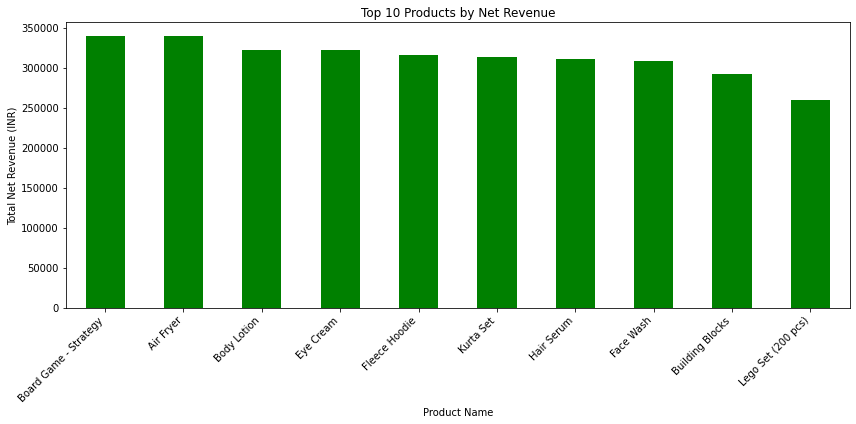

Insight: This chart shows the top 10 revenue-generating products, helping identify which products are most important for the business.


In [8]:
# Chart 5: Your choice - Any insight you find interesting
# Insight: Top 10 products by revenue (shows which products drive the most sales)
top_products = df.groupby('product_name')['net_revenue_inr'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_products.plot(kind='bar', color='green')
plt.xlabel('Product Name')
plt.ylabel('Total Net Revenue (INR)')
plt.title('Top 10 Products by Net Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Insight: This chart shows the top 10 revenue-generating products, helping identify which products are most important for the business.")